# <img style="float: left; padding-right: 20px; width: 200px" src="https://raw.githubusercontent.com/raxlab/imt2200-data/main/media/logo.jpg">  IMT 2200 - Introducción a Ciencia de Datos
**Pontificia Universidad Católica de Chile**<br>
**Instituto de Ingeniería Matemática y Computacional**<br>
**Semestre 2025-S2**<br>
**Profesor:** Rodrigo A. Carrasco <br>

# <h1><center>Tarea 03: Exploración de datos </center></h1>

**Fecha de Entrega:** 28 de octubre de 2025, a las 23:59.

**Fecha de publicación**: 14 de octubre de 2025.

**Formato de entrega:** Notebook ejecutado y comentado (`.ipynb`) en el módulo de Tarea 03 habilitado en Canvas.

## Instrucciones

- Esta Tarea debe desarrollarse de manera totalmente *individual*, de acuerdo a lo establecido en la sección de Integridad Académica en el programa del curso.
- La Tarea debe ser desarrollada en lenguaje de programación Python y la entrega en formato Jupyter Notebook.
- El desarrollo del Notebook debe ser claro y ordenado, incluyendo anotaciones (markdown) y comentarios que permitan seguir fácilmente el código y los pasos implementados a los correctores, y siguiendo buenas prácticas de programación. La presentación y claridad del notebook y código forman parte de la evaluación de la tarea.
- Notebook **autocontenible** que:
   - Ejecute sin errores todas las celdas.
  - Contenga tanto el código como los comentarios y explicaciones necesarias.
  - Incluya visualizaciones claras y correctamente etiquetadas.
- No se aceptarán notebooks con celdas rotas o que dependan de rutas externas no indicadas en la tarea.

- Deben hacer sus consultas y comentarios sobre la Tarea a través del canal de Tareas en el Foro del curso en Canvas.

---

## 1. Objetivos

- Aplicar los conceptos iniciales de manejo de datos y análisis exploratorio vistos en clases.
- Practicar la lectura, limpieza y manipulación de datos en Python.
- Desarrollar habilidades para visualizar y describir patrones y tendencias en conjuntos de datos reales.
- Fomentar la capacidad de comunicar resultados de forma clara y fundamentada.

### 1.1 Objetivo educacional

Esta Tarea tiene como objetivo que los estudiantes desarrollen la capacidad de manejar algunas de las librerías centrales para el desarrollo de Ciencia de Datos, con foco en la lectura y exploración de datos. 

Para los ejercicios a continuación, usted deberá leer, inspeccionar, manipular y graficar conjuntos de datos en distintos formatos, de manera de responder las preguntas de cada parte de la Tarea.

### 1.2 Pregunta de ciencia de datos

En esta tarea vamos a analizar la distribución de vulneribilidad escolar para distintos establecimientos educacionales en Chile, desde enseñanza parvularia hasta enseñanza media. Específicamente, queremos entender cómo se comporta un índice de vulnerabilidad en relación a variables como ruralidad, tipo de dependencia y comuna del establecimiento.

---

## 2. Datos

En este estudio, trabajaremos con los resultados publicados anualmente sobre por la JUNAEB
sobre vulnerabilidad de establecimientos educacionales en todo el territorio nacional. Estos resultados están disponibles en la siguiente página web:

* Índices de Vulnerabilidad (JUNAEB): https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

Adicionalmente, para visualizar las variables, utilizaremos los mapas vectoriales que disponibiliza la Biblioteca del Congreso Nacional (BCN):

* Mapoteca BCN: https://www.bcn.cl/siit/mapas_vectoriales/index_html

### 2.1 Descarga de datos y conceptos generales (1 punto)

Acceda a los links entregados y descargue el set de datos del **Índice de Vulnerabilidad Multidimensional de Establecimientos Educacionales** para el año 2025. Este debería ser un documento XLSX con múltiples pestañas, incluyendo entre estas un índice que describe las columnas presentes en la base de datos.
Descargue además los archivos correspondientes a la **División comunal: polígonos de las comunas de Chile**. Este se descarga en formato `.zip` y contiene archivos shapefile para visualizar las comunas del país.

Investigue sobre este índice y responda de manera concisa: 
* ¿En qué consiste el IVM? ¿Qué rango de valores toma y qué significan? 
* ¿Cómo se obtiene el IVM de un establecimiento educacional?



Respuesta: 
Según lo entendido de https://www.junaeb.cl/medicion-la-vulnerabilidad-ivm/

-El Índice de Vulnerabilidad Multidimensional (IVM) es una medida generada a partir de la correlación de variables que representan los factores mas relevantes del estudiante, según su trayectoria escolar. Los puntajes se encuentran entre 0 y 100, a mayor puntaje, mayor vulneravilidad.

## 3. Lectura y limpieza de datos (1 punto)

### 3.1 Datos de establecimientos (0.5 puntos)
El archivo descargado contiene información sobre establecimientos de cuatro tipos: Parvularia, Primer Ciclo Básica, Segundo Ciclo Básica y Media.
Cargue los datos de los establecimientos en cuatro DataFrames distintos.

Revise cada uno de sus sets de datos y haga un proceso de limpieza si lo considera necesario (manejo de valores nulos, duplicados, inválidos, transformación de tipos de datos, etc). De haberlos, identifique qué atributos son categóricos y transforme los tipos de columna de acuerdo a su decisión, mostrando todos los posibles valores de cada categoría.

Justifique **todas** sus decisiones, **incluso** si decide no realizar una limpieza o transformación.

Finalmente, responda:

* a. ¿Cuántos establecimientos tiene cada set de datos?
* b. ¿Cuánto espacio en memoria ocupan en total los 4 datasets?
* c. ¿Cuántos estudiantes fueron evaluados en todo el país para cada nivel de enseñanza para el año 2025?


In [1]:
import os
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_parvularia_raw = pd.read_excel(os.path.join('data', 'IVM_Establecimientos_2025-2.xlsx'),
                                  sheet_name='Parvularia')

df_parvularia_raw.isna().any().sum()  # No hay valores vacios

df_parvularia_raw['DS_TIPO_DEPENDENCIA'] = df_parvularia_raw['DS_TIPO_DEPENDENCIA'].astype('category')
df_parvularia_raw['DS_RURALIDAD'] = df_parvularia_raw['DS_RURALIDAD'].astype('category')

df_parvularia_raw.info()  # Todas las columnas tienen su tipo de dato corresponiente
df_parvularia_raw.describe()  # Los mínimos y máximos se mantienen en sus rasgos esperados

# alumnos encuestados = total de datos alumos
df_parvularia_raw['total_encuestados_real_data'] = df_parvularia_raw[['IVM Bajo', 'IVM Medio', 'IVM Alto', 'IVM Muy Alto']].sum(axis=1)
df_parvularia_raw[df_parvularia_raw['total_encuestados_real_data'] != df_parvularia_raw['N EVALUADO']].shape[0]
# concuerdan
# No requiere mayor limpieza

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6163 entries, 0 to 6162
Data columns (total 21 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   ID_RBD                    6163 non-null   int64   
 1   DV_RBD                    6163 non-null   int64   
 2   DS_NOM_ESTABLE            6163 non-null   object  
 3   DS_TIPO_DEPENDENCIA       6163 non-null   category
 4   DS_RURALIDAD              6163 non-null   category
 5   ID_REGION_ESTABLE         6163 non-null   int64   
 6   ID_PROVINCIA_ESTABLE      6163 non-null   int64   
 7   ID_COMUNA_ESTABLE         6163 non-null   int64   
 8   DS_COMUNA_ESTABLE         6163 non-null   object  
 9   N EVALUADO                6163 non-null   int64   
 10  IVM Establecimiento       6163 non-null   float64 
 11  IVM Bajo                  6163 non-null   int64   
 12  IVM Medio                 6163 non-null   int64   
 13  IVM Alto                  6163 non-null   int64 

0

In [3]:
df_basico1_raw = pd.read_excel(os.path.join('data', 'IVM_Establecimientos_2025-2.xlsx'),
                                  sheet_name='1º Ciclo Básico')

df_basico1_raw.isna().any().sum()  # No hay valores vacios

# categoria para las variables str que no son nombres, sino arbitrariamente una categoría
df_basico1_raw['DS_TIPO_DEPENDENCIA'] = df_basico1_raw['DS_TIPO_DEPENDENCIA'].astype('category')
df_basico1_raw['DS_RURALIDAD'] = df_basico1_raw['DS_RURALIDAD'].astype('category')

df_basico1_raw.info()  # Todas las columnas tienen su tipo de dato corresponiente
df_basico1_raw.describe()  # Los mínimos y máximos se mantienen en sus rasgos esperados

# alumnos encuestados = total de datos alumos
df_basico1_raw['total_encuestados_real_data'] = df_basico1_raw[['IVM Bajo', 'IVM Medio', 'IVM Alto', 'IVM Muy Alto']].sum(axis=1)
df_basico1_raw[df_basico1_raw['total_encuestados_real_data'] != df_basico1_raw['N EVALUADO']].shape[0]
# concuerdan
# No requiere mayor limpieza

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7082 entries, 0 to 7081
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ID_RBD                7082 non-null   int64   
 1   DV_RBD                7082 non-null   int64   
 2   DS_NOM_ESTABLE        7082 non-null   object  
 3   DS_TIPO_DEPENDENCIA   7082 non-null   category
 4   DS_RURALIDAD          7082 non-null   category
 5   ID_REGION_ESTABLE     7082 non-null   int64   
 6   ID_PROVINCIA_ESTABLE  7082 non-null   int64   
 7   ID_COMUNA_ESTABLE     7082 non-null   int64   
 8   DS_COMUNA_ESTABLE     7082 non-null   object  
 9   N EVALUADO            7082 non-null   int64   
 10  IVM Establecimiento   7082 non-null   float64 
 11  IVM Bajo              7082 non-null   int64   
 12  IVM Medio             7082 non-null   int64   
 13  IVM Alto              7082 non-null   int64   
 14  IVM Muy Alto          7082 non-null   int64   
 15  IVM 

0

In [4]:
df_basico2_raw = pd.read_excel(os.path.join('data', 'IVM_Establecimientos_2025-2.xlsx'),
                                  sheet_name='2º Ciclo Básico')

df_basico2_raw.isna().any().sum()  # No hay valores vacios

# categoria para las variables str que no son nombres, sino arbitrariamente una categoría
df_basico2_raw['DS_TIPO_DEPENDENCIA'] = df_basico2_raw['DS_TIPO_DEPENDENCIA'].astype('category')
df_basico2_raw['DS_RURALIDAD'] = df_basico2_raw['DS_RURALIDAD'].astype('category')

df_basico2_raw.info()  # Todas las columnas tienen su tipo de dato corresponiente
df_basico2_raw.describe()  # Los mínimos y máximos se mantienen en sus rasgos esperados

# alumnos encuestados = total de datos alumos
df_basico2_raw['total_encuestados_real_data'] = df_basico2_raw[['IVM Bajo', 'IVM Medio', 'IVM Alto', 'IVM Muy Alto']].sum(axis=1)
df_basico2_raw[df_basico2_raw['total_encuestados_real_data'] != df_basico2_raw['N EVALUADO']].shape[0]
# concuerdan
# No requiere mayor limpieza

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5662 entries, 0 to 5661
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ID_RBD                5662 non-null   int64   
 1   DV_RBD                5662 non-null   int64   
 2   DS_NOM_ESTABLE        5662 non-null   object  
 3   DS_TIPO_DEPENDENCIA   5662 non-null   category
 4   DS_RURALIDAD          5662 non-null   category
 5   ID_REGION_ESTABLE     5662 non-null   int64   
 6   ID_PROVINCIA_ESTABLE  5662 non-null   int64   
 7   ID_COMUNA_ESTABLE     5662 non-null   int64   
 8   DS_COMUNA_ESTABLE     5662 non-null   object  
 9   N EVALUADO            5662 non-null   int64   
 10  IVM Establecimiento   5662 non-null   float64 
 11  IVM Bajo              5662 non-null   int64   
 12  IVM Medio             5662 non-null   int64   
 13  IVM Alto              5662 non-null   int64   
 14  IVM Muy Alto          5662 non-null   int64   
dtypes: c

0

In [5]:
df_media_raw = pd.read_excel(os.path.join('data', 'IVM_Establecimientos_2025-2.xlsx'),
                                  sheet_name='Media')
df_media_raw.isna().any().sum()  # No hay valores vacios

# categoria para las variables str que no son nombres, sino arbitrariamente una categoría
df_media_raw['DS_TIPO_DEPENDENCIA'] = df_media_raw['DS_TIPO_DEPENDENCIA'].astype('category')
df_media_raw['DS_RURALIDAD'] = df_media_raw['DS_RURALIDAD'].astype('category')

df_media_raw.info()  # Todas las columnas tienen su tipo de dato corresponiente
df_media_raw.describe()  # Los mínimos y máximos se mantienen en sus rasgos esperados

# alumnos encuestados = total de datos alumos
df_media_raw['total_encuestados_real_data'] = df_media_raw[['IVM Bajo', 'IVM Medio', 'IVM Alto', 'IVM Muy Alto']].sum(axis=1)
df_media_raw[df_media_raw['total_encuestados_real_data'] != df_media_raw['N EVALUADO']].shape[0]
# concuerdan
# No requiere mayor limpieza

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2618 entries, 0 to 2617
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype   
---  ------                --------------  -----   
 0   ID_RBD                2618 non-null   int64   
 1   DV_RBD                2618 non-null   int64   
 2   DS_NOM_ESTABLE        2618 non-null   object  
 3   DS_TIPO_DEPENDENCIA   2618 non-null   category
 4   DS_RURALIDAD          2618 non-null   category
 5   ID_REGION_ESTABLE     2618 non-null   int64   
 6   ID_PROVINCIA_ESTABLE  2618 non-null   int64   
 7   ID_COMUNA_ESTABLE     2618 non-null   int64   
 8   DS_COMUNA_ESTABLE     2618 non-null   object  
 9   N EVALUADO            2618 non-null   int64   
 10  IVM Establecimiento   2618 non-null   float64 
 11  IVM Bajo              2618 non-null   int64   
 12  IVM Medio             2618 non-null   int64   
 13  IVM Alto              2618 non-null   int64   
 14  IVM Muy Alto          2618 non-null   int64   
dtypes: c

0

In [6]:
print('a:')
for df, name in zip(
        [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media']):
    print(f'Establecimientos de {name}: {len(df['ID_RBD'].unique())}')
print('\nb:')
total = 0
for df, name in zip(
        [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media']):
    mem = df.memory_usage(deep=True).sum()
    total += mem
    print(f'DataFrame de {name}: {mem} bytes, {(mem / 1024**2):.2f} MB')
print(f'Total: {total} bytes, {(total / 1024**2):.2f} MB')
print('\nc:')
for df, name in zip(
        [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media']):
    print(f'Alumnos evaluados de {name}: {df['N EVALUADO'].sum()}')

a:
Establecimientos de Parvularia: 6163
Establecimientos de 1º Ciclo Básica: 7082
Establecimientos de 2º Ciclo Básica: 5662
Establecimientos de Media: 2618

b:
DataFrame de Parvularia: 1772357 bytes, 1.69 MB
DataFrame de 1º Ciclo Básica: 2132601 bytes, 2.03 MB
DataFrame de 2º Ciclo Básica: 1347847 bytes, 1.29 MB
DataFrame de Media: 630744 bytes, 0.60 MB
Total: 5883549 bytes, 5.61 MB

c:
Alumnos evaluados de Parvularia: 255506
Alumnos evaluados de 1º Ciclo Básica: 882881
Alumnos evaluados de 2º Ciclo Básica: 484540
Alumnos evaluados de Media: 901899


### 3.2 Datos geográficos (0.5 puntos)

Cargue en un GeoDataFrame de GeoPandas la información de los polígonos de cada comuna del país.

Como realizamos en la Tarea pasada, puede transformar el Coordinate Reference System (CRS) a EPSG 4326, para tener la información de los puntos de los polígonos con latitud y longitud.

In [7]:
# desde la carpeta descomprimida, ya que creo que no se especificó nada al respecto
comuna_shp = gpd.read_file(os.path.join('data', 'Comunas', 'comunas.shp'))
comuna_shp = comuna_shp.to_crs('EPSG:4326')

## 4. Análisis descriptivo (1.5 puntos)

En esta sección haremos una exploración preliminar de los 4 sets de datos cargados. Para cada una de las siguientes preguntas, sustente su respuesta con al menos un gráfico y su análisis respectivo.

**Recomendación:** puede utilizar el método `subplots()` de `matplotlib.pyplot` para facilitar la visualización de múltiples gráficos a la vez.

### 4.1 Ruralidad (0.8 pts)
* a. ¿Cuál es la cantidad de establecimientos rurales vs urbanos según nivel de enseñanza?
* b. ¿Cómo se distribuye el IVM según nivel de enseñanza y ruralidad?


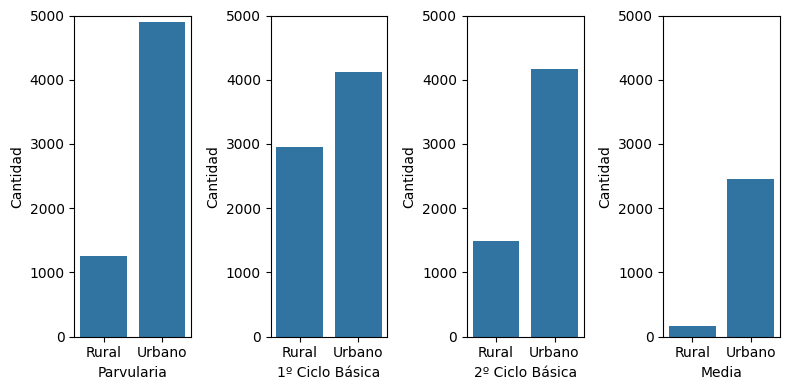

In [8]:
fig, ax = plt.subplots(1, 4, figsize=(8, 4))

for i, (df, x_label) in enumerate(zip(
        [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media'])):
    
    sns.countplot(data=df, x='DS_RURALIDAD', ax=ax[i])
    
    ax[i].set_xlabel(x_label)
    ax[i].set_ylabel('Cantidad')
    ax[i].set_ylim(0, 5000)

plt.tight_layout()
plt.show()

#### a.
Se puede que en los 4 niveles hay mas establecimientos urbanos que rurales, con brechas mas grandes que razón 2(urbanos):1(rurales), a excepción del primer ciclo de básica, con una razón cercana a 4:3

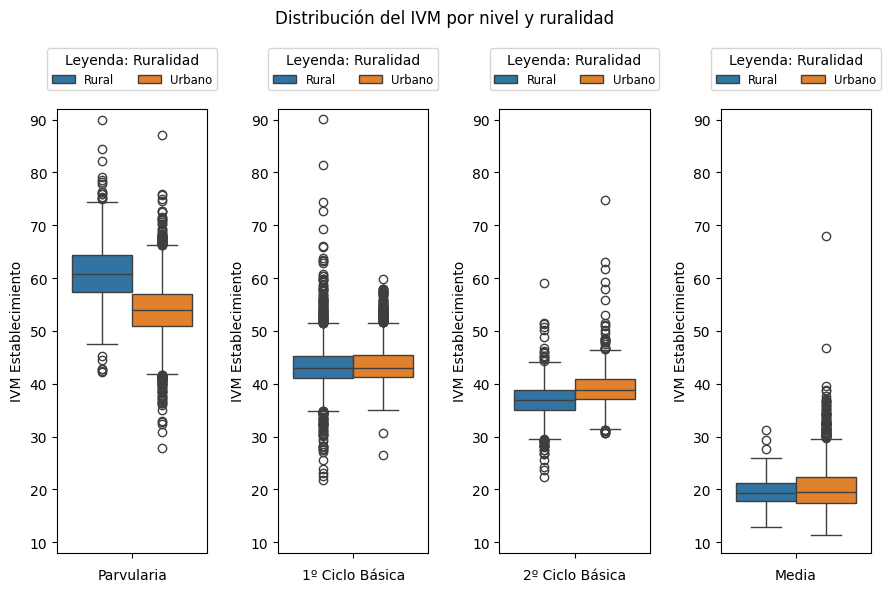

In [9]:
fig, ax = plt.subplots(1, 4, figsize=(9, 6))

for i, (df, x_label) in enumerate(zip(
        [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media'])):
    
    sns.boxplot(data=df.sort_values('DS_RURALIDAD'), y='IVM Establecimiento', hue='DS_RURALIDAD', ax=ax[i])
    ax[i].set_ylim(8, 92)
    
    ax[i].set_xlabel(x_label)
    ax[i].set_ylabel('IVM Establecimiento')
    ax[i].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize='small', title='Leyenda: Ruralidad')

fig.suptitle('Distribución del IVM por nivel y ruralidad')

plt.tight_layout()
plt.show()

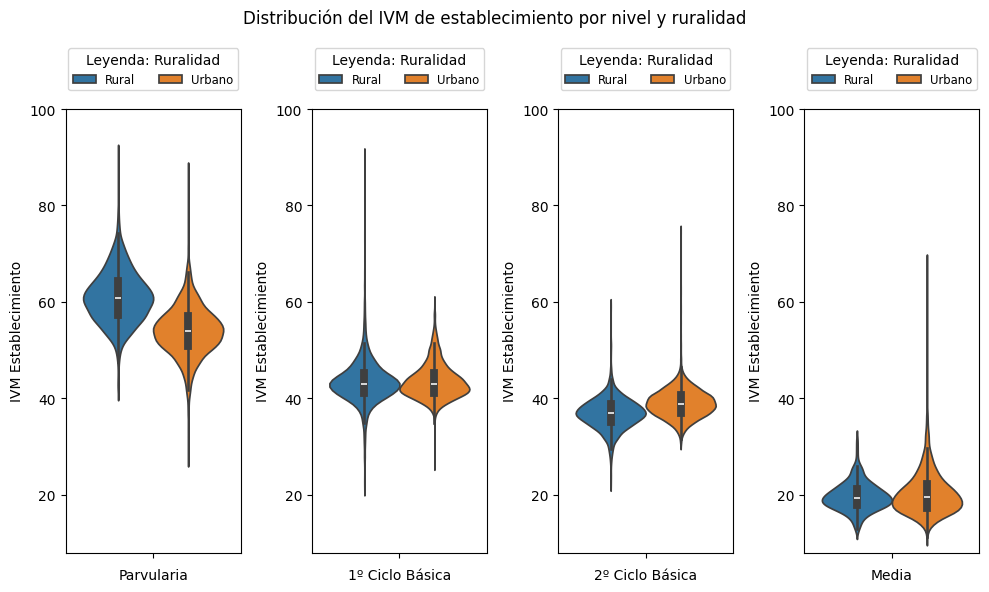

In [10]:
fig, ax = plt.subplots(1, 4, figsize=(10, 6))

for i, (df, x_label) in enumerate(zip(
        [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media'])):
    
    sns.violinplot(data=df.sort_values('DS_RURALIDAD'), y='IVM Establecimiento', hue='DS_RURALIDAD', ax=ax[i])
    ax[i].set_ylim(8, 100)
    
    ax[i].set_xlabel(x_label)
    ax[i].set_ylabel('IVM Establecimiento')
    ax[i].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, fontsize='small', title='Leyenda: Ruralidad')

fig.suptitle('Distribución del IVM de establecimiento por nivel y ruralidad')

plt.tight_layout()
plt.show()

#### b
Viendo los gráficos de cajón y de violín, vemos que a medida que el estudiante cursa ciclos mas altos, el IVM va disminuyendo tanto en establecimientos rurales como urbanos. En parvularia el IVM es mas alto en establecimientos rurales, en primer ciclo y en media tienen una mediana relativamente parecida, mientras que en segundo ciclo la media de IVM urbano es mas alto que la media rural

### 4.2 Tipo de establecimiento (0.7 pts)

* ¿Cómo es la distribución del IVM promedio de los establecimientos según tipo de dependencia y nivel de enseñanza? 

In [11]:
palette_dependencia = {
    'Servicio Local de Educación(SLE)': '#1f77b4',
    'Particular Subvencionado': '#2ca02c',
    'Municipal DAEM': '#d62728',
    'Corporación Municipal': '#ff7f0e',
    'Administración Delegada (C. P. 3166)': '#9467bd'
}

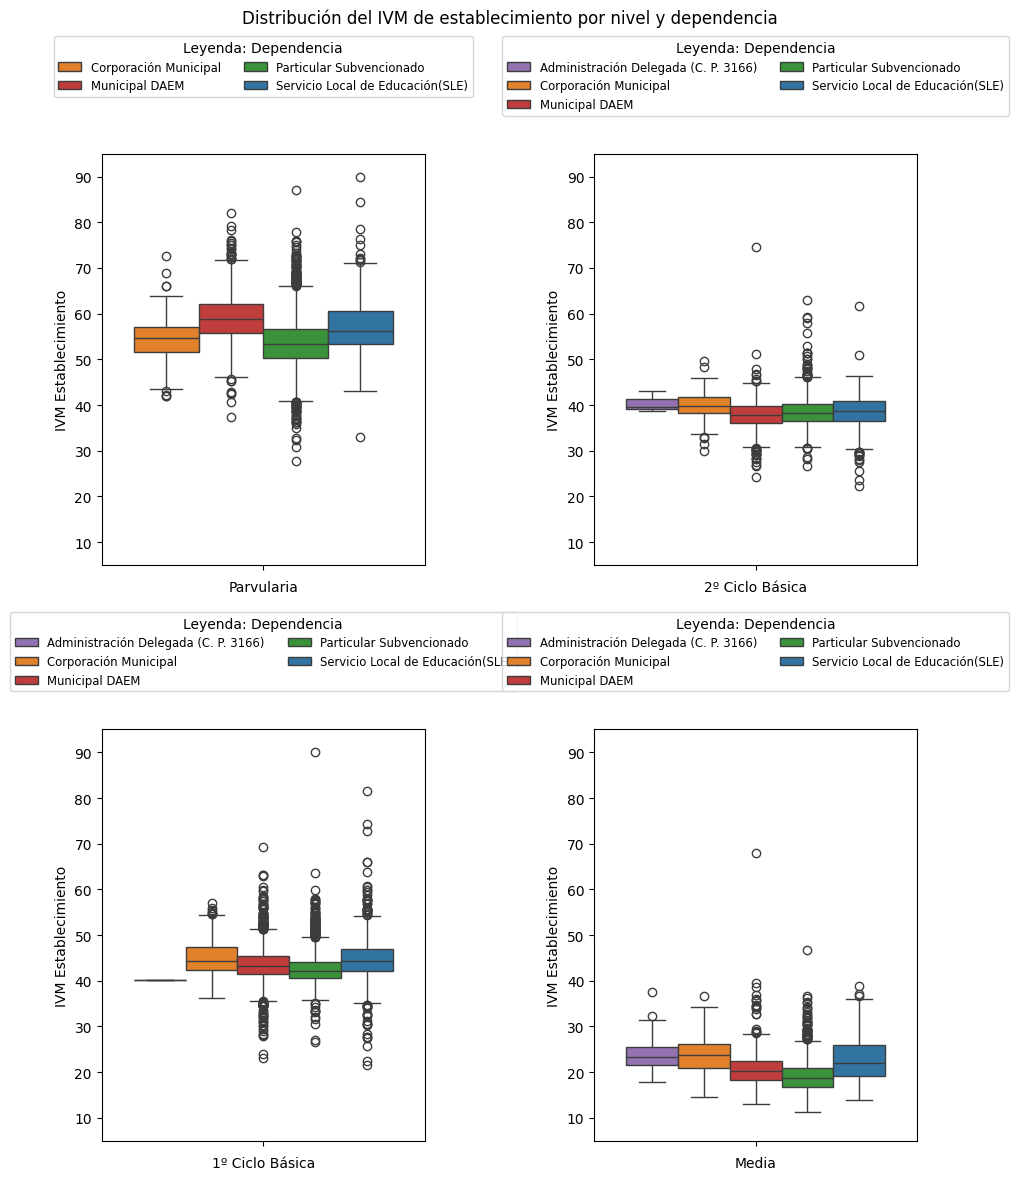

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(10, 12))

for i, j, df, x_label in zip(
    [0, 1, 0, 1], [0, 0, 1, 1],
    [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
    ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media']):

    sns.boxplot(data=df.sort_values('DS_TIPO_DEPENDENCIA'), y='IVM Establecimiento', hue='DS_TIPO_DEPENDENCIA', ax=ax[i][j],
                  palette=palette_dependencia)
    ax[i][j].set_ylim(5, 95)
    
    ax[i][j].set_xlabel(x_label)
    ax[i][j].set_ylabel('IVM Establecimiento')
    ax[i][j].legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=2, fontsize='small', title='Leyenda: Dependencia')

fig.suptitle('Distribución del IVM de establecimiento por nivel y dependencia')

plt.tight_layout()
plt.show()

In [13]:
cant_1 = df_basico1_raw[df_basico1_raw['DS_TIPO_DEPENDENCIA'] == 'Administración Delegada (C. P. 3166)']
cant_2 = df_basico2_raw[df_basico2_raw['DS_TIPO_DEPENDENCIA'] == 'Administración Delegada (C. P. 3166)']
cant_m = df_media_raw[df_media_raw['DS_TIPO_DEPENDENCIA'] == 'Administración Delegada (C. P. 3166)']
print(cant_1.shape[0], cant_2.shape[0], cant_m.shape[0])
# Dada la baja cantidad de establecimientos 'Administración Delegada (C. P. 3166)' en los ciclos de basico, no se considerarán

1 3 70


Con estos graficos, nuevamente vemos que a medida que el estudiante cursa ciclos mas altos, el IVM va disminuyendo.
- Parvularia, Particular Suvencionado con la media mas baja,
- Primer ciclo Básica, SLE y Corporación municipal con las medianas mas altas, Particulares Subvencionados con la mediana mas baja
- Segundo ciclo Básica, Establecimientos Municipales con la mediana de IVM mas baja
- Media, El IVM promedio mas bajo entre los 4 niveles de enseñanza, establecimientos públicos subvencionados con la media mas baja.

### 4.3 Pregunta Bono: Dimensiones de vulnerabilidad (1 punto)

Para los niveles de enseñanza Parvularia y Básica Primer ciclo (1-4º), tenemos información sobre distintas dimensiones de que se utilizan para calcular el IVM, como condición socioeconómica familiar y comunal, salud, etc. 

* Para todo Chile, en promedio, ¿cuál es la dimensión con mayor puntaje de IVM para cada uno de estos dos niveles de enseñanza?

In [14]:
df_parvularia_raw.describe().iloc[1:2, -7:-1]

,IVM Salud,IVM CSE Familiar,IVM Estimulación y Apoyo,IVM Familia,IVM CSE Comunal,IVM Derechos
mean,27.910199,43.19421,43.095565,70.667085,18.127686,14.21129


In [15]:
df_basico1_raw.describe().iloc[1:2, -9:-1]

,IVM Salud,IVM Discapacidad,IVM Educación,IVM Habitabilidad,IVM Familiar,IVM Participación,IVM CSE Familia,IVM CSE Comunal
mean,43.10235,5.924766,13.038839,20.741263,32.196868,5.3268,54.390762,22.728506


- Para todo Chile, en promedio, para el nivel Parvularia la dimensión con mayor puntaje de IVM es Familia
- Para todo Chile, en promedio, para el nivel 1º ciclo básica la dimensión con mayor puntaje de IVM es CSE Familia

## 5. Agrupación de bases de datos (2 puntos)

El objetivo de esta sección será agrupar los establecimientos según la comuna en la que se encuentran para obtener un resumen general sobre la vulnerabilidad escolar en cada una de ellas. Al finalizar esta sección, tendremos un nuevo DataFrame `agg_comunal` que contenga, al menos, la siguiente información:

* Comuna (nombre y ID)
* Región (ID)
* Cantidad de establecimientos rurales de la comuna
* Cantidad de establecimientos urbanos de la comuna
* Cantidad total de establecimientos de la comuna
* Porcentaje de establecimientos rurales
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna
* Objeto geometry de GeoPandas correspondiente al polígono de la comuna respectiva

Armaremos este DataFrame paso a paso.

### 5.1 Cálculo de IVM promedio por comuna (0.8 pts)

Primero, para cada uno sus 4 DataFrames, calcule el promedio de la columna `IVM Establecimiento` según comuna. Almacene este valor en una nueva columna llamada `IVM Promedio {NIVEL DE ENSEÑANZA}` (por ejemplo, para enseñanza parvularia, cree la columna `IVM Promedio Parvularia`).

Junte los 4 resultados que obtuvo en un solo DataFrame `ivm_comunal` que contenga:
* Comuna (nombre y ID)
* Región (ID)
* IVM Promedio Parvularia de la comuna
* IVM Promedio Básica Primer Ciclo de la comuna
* IVM Promedio Básica Segundo Ciclo de la comuna
* IVM Promedio Media de la comuna

Ponga siempre atención al tamaño de sus DataFrames: como estamos agrupando comunalmente, estos siempre debiesen tener una cantidad de filas igual a las comunas de Chile.

In [16]:
dfs = []

for df, nivel in zip(
        [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media']):
    new_df = df.groupby(['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'])['IVM Establecimiento'].mean().reset_index()
    new_df.rename(columns={'IVM Establecimiento': f'IVM Promedio {nivel}'}, inplace=True)
    dfs.append(new_df)

ivm_comunal = dfs[0]

for df in dfs[1:]:
    ivm_comunal = pd.merge(ivm_comunal, df, on=['ID_REGION_ESTABLE', 'ID_COMUNA_ESTABLE', 'DS_COMUNA_ESTABLE'], how='outer')

### 5.2 Establecimientos por comuna y ruralidad (0.8 pts)

Ahora contaremos la cantidad de establecimientos por comuna según ruralidad. Como buscamos la cantidad total de establecimientos, consideramos establecimientos de todos los niveles educacionales vistos. Para esto, combine los 4 DataFrames que cargó y genere un nuevo DataFrame `estab_comunal` que contenga:

* Comuna (ID)
* Cantidad de establecimientos rurales
* Cantidad de establecimientos urbanos
* Cantidad total de establecimientos
* Porcentaje de establecimientos rurales (Establecimientos rurales / Total establecimientos * 100)

Tenga en cuenta de que pueden aparecer establecimientos duplicados al combinar estos 4 DataFrames (por ejemplo, establecimientos que imparten múltiples niveles de enseñanza, desde 1º básico hasta 4º medio). Preocúpese de manejar estos casos antes de agrupar sus datos según ruralidad.

In [17]:
dfs = []

for df, nivel in zip(
        [df_parvularia_raw, df_basico1_raw, df_basico2_raw, df_media_raw],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media']):
    new_df = df[['ID_RBD', 'DV_RBD', 'ID_COMUNA_ESTABLE', 'DS_RURALIDAD']]
    dfs.append(new_df)

estab_comunal = pd.concat(dfs, axis=0, ignore_index=True)
estab_comunal = estab_comunal.drop_duplicates()
estab_comunal = estab_comunal.groupby('ID_COMUNA_ESTABLE')['DS_RURALIDAD'].value_counts().unstack(fill_value=0).reset_index()
estab_comunal['Total Establecimientos'] = estab_comunal['Rural'].astype(int) + estab_comunal['Urbano'].astype(int)
estab_comunal['P Establecimientos Rurales'] = estab_comunal['Rural'].astype(int) / estab_comunal['Total Establecimientos'].astype(int) * 100

### 5.3 Unión de bases de datos y polígonos (0.4 pts)

Finalmente, vamos a generar el DataFrame `agg_comunal` con la información de los dos previos DataFrames creados.
Combine la información de las dos secciones anteriores para crear su base de datos unificada. Por último, agregue la columna `geometry` con la información geográfica de cada comuna.

In [18]:
agg_comunal = pd.merge(comuna_shp[['cod_comuna', 'geometry']], ivm_comunal, left_on='cod_comuna', right_on='ID_COMUNA_ESTABLE', how='left')
agg_comunal = pd.merge(agg_comunal, estab_comunal, on='ID_COMUNA_ESTABLE', how='left')
print(type(agg_comunal)) # geodataframe

<class 'geopandas.geodataframe.GeoDataFrame'>


## 6. Análisis de vulnerabilidad por comuna (1.5 puntos)

### 6.1 Mapa de calor (0.8 pts)

Genere mapas de calor de las comunas de Chile según el IVM promedio de los establecimientos educacionales. Realice esto para cada etapa de enseñanza (Parvularia, Básica 1, Básica 2 y Media). Analice y comente sus resultados:
* ¿Cómo se diferencia la vulnerabilidad en distintos sectores del país según nivel de enseñanza?

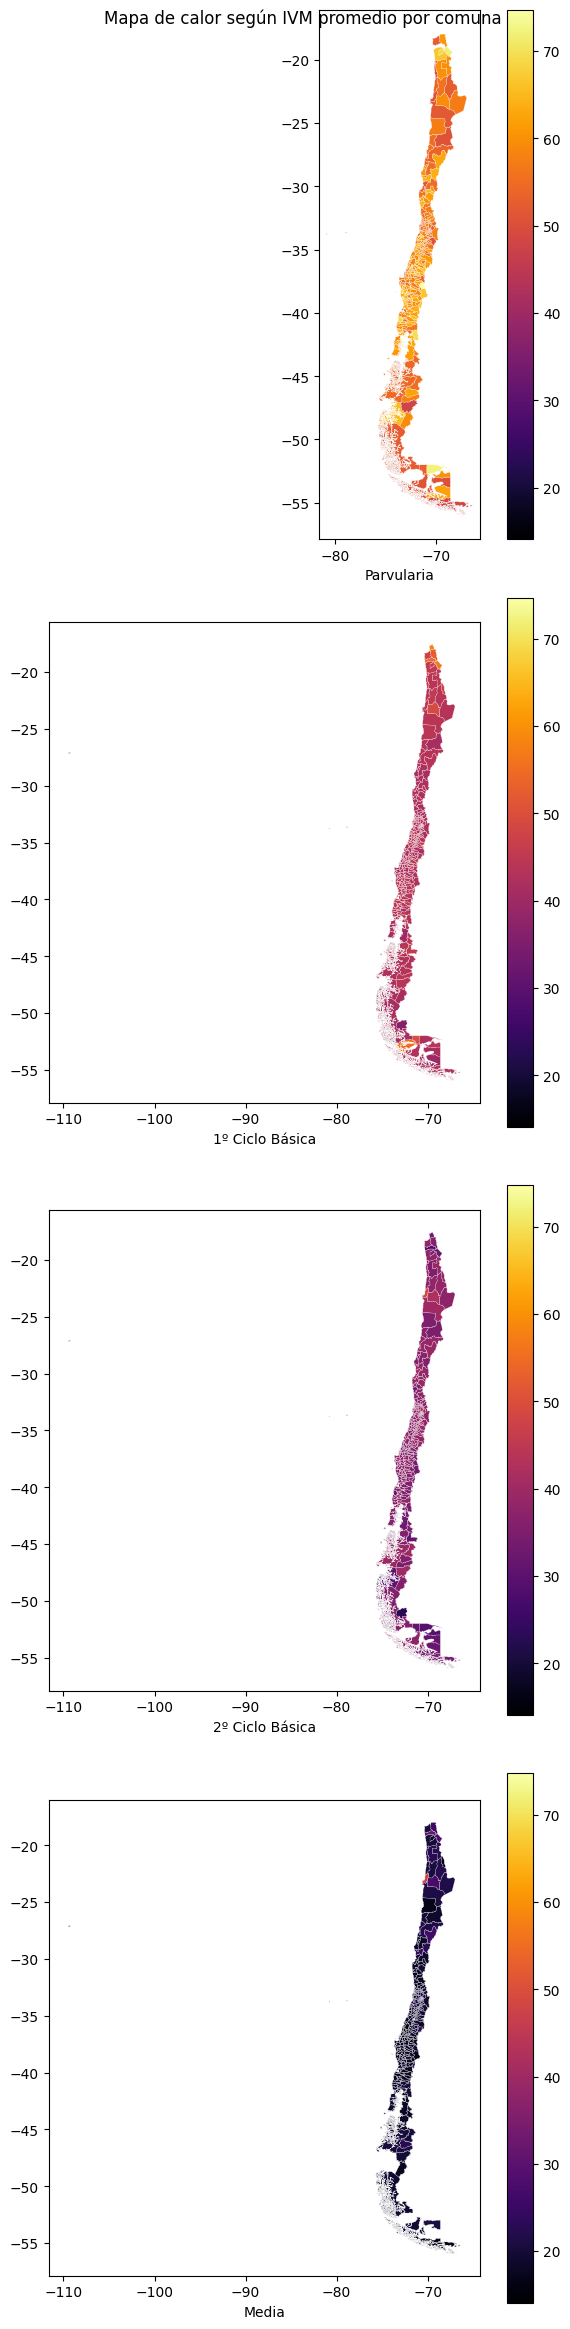

In [19]:
vmin = agg_comunal[['IVM Promedio Parvularia', 'IVM Promedio 1º Ciclo Básica', 'IVM Promedio 2º Ciclo Básica', 'IVM Promedio Media']].min().min()
vmax = agg_comunal[['IVM Promedio Parvularia', 'IVM Promedio 1º Ciclo Básica', 'IVM Promedio 2º Ciclo Básica', 'IVM Promedio Media']].max().max()

fig, ax = plt.subplots(4, 1, figsize=(6, 24))

for i, (column, x_label) in enumerate(zip(
        ['IVM Promedio Parvularia', 'IVM Promedio 1º Ciclo Básica', 'IVM Promedio 2º Ciclo Básica', 'IVM Promedio Media'],
        ['Parvularia', '1º Ciclo Básica', '2º Ciclo Básica', 'Media'])):

    ax[i].set_xlabel(x_label)
    agg_comunal.plot(ax=ax[i], column=column, cmap='inferno', edgecolor="white", linewidth=0.15, legend=True,
                    vmin=vmin, vmax=vmax)

fig.suptitle(f'Mapa de calor según IVM promedio por comuna')

plt.tight_layout()
plt.show()

Comentarios y análisis: Se relaciones de manera directa; En niveles de enseñanza mas altos, el IVM, en promedio, disminuye 

### 6.2 Relación entre ruralidad comunal y vulnerabilidad (0.7 pts)

En la sección **5.2** definimos el **porcentaje de ruralidad** de cada comuna según la cantidad de establecimientos rurales en cada una. Analice y visualice los datos en `agg_comunal` para responder la siguiente pregunta:

* ¿Hay alguna correlación entre el IVM promedio y el porcentaje de ruralidad en las comunas de Chile?

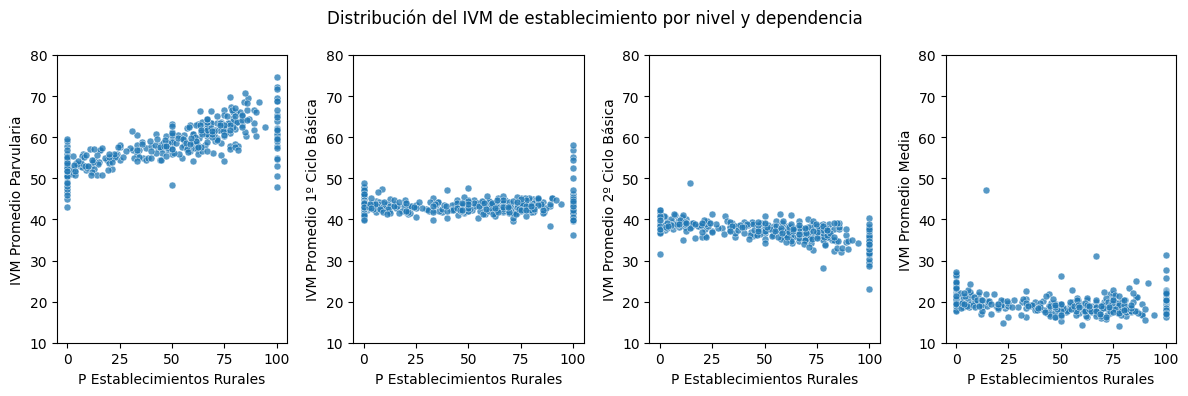

In [20]:
fig, ax = plt.subplots(1, 4, figsize=(12, 4))

for i, column in enumerate([
    'IVM Promedio Parvularia', 'IVM Promedio 1º Ciclo Básica', 'IVM Promedio 2º Ciclo Básica', 'IVM Promedio Media']):

    sns.scatterplot(data=agg_comunal, x='P Establecimientos Rurales', y=column, ax=ax[i],
                   s=25, alpha=0.75)
    ax[i].set_ylim(10, 80)

fig.suptitle('Distribución del IVM de establecimiento por nivel y dependencia')

plt.tight_layout()
plt.show()

Se pueden ver en los bordes de porcentaje 'lineas' de puntos, esto quizá se deba a comunas con un único establecimiento

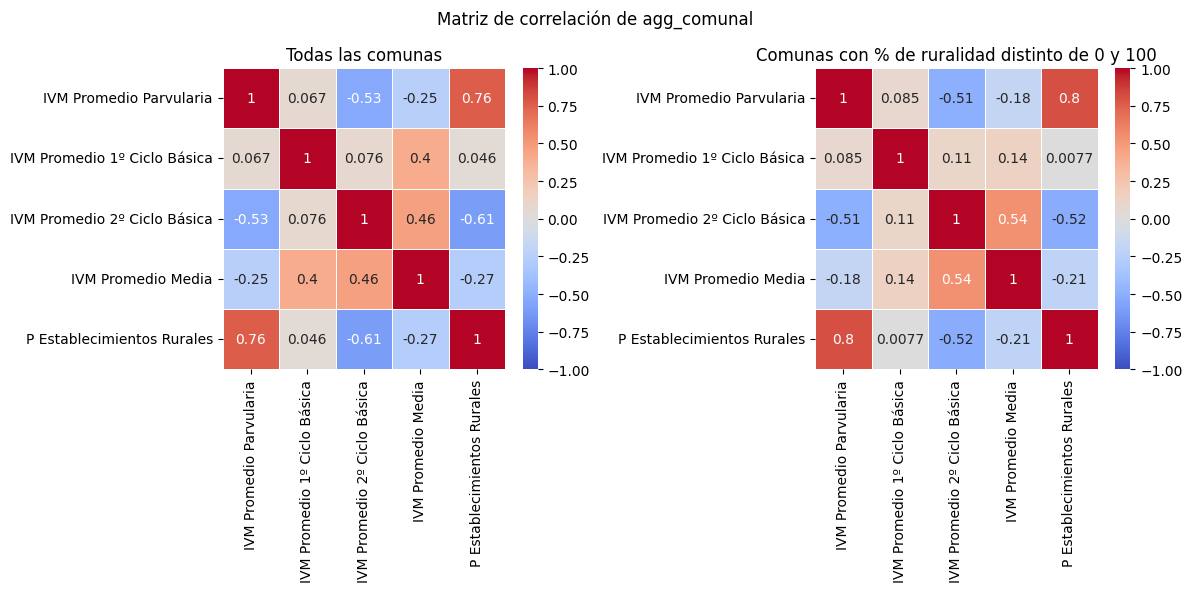

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 6))

corr = agg_comunal[[
    'IVM Promedio Parvularia', 'IVM Promedio 1º Ciclo Básica', 'IVM Promedio 2º Ciclo Básica', 'IVM Promedio Media',
    'P Establecimientos Rurales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, ax=ax[0], vmin=-1, vmax=1)
ax[0].set_title('Todas las comunas')

temporal = agg_comunal[agg_comunal['P Establecimientos Rurales'] != 0].copy()
corr = temporal[temporal['P Establecimientos Rurales'] != 100][[
    'IVM Promedio Parvularia', 'IVM Promedio 1º Ciclo Básica', 'IVM Promedio 2º Ciclo Básica', 'IVM Promedio Media',
    'P Establecimientos Rurales']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', linewidths=0.5, ax=ax[1], vmin=-1, vmax=1)
ax[1].set_title('Comunas con % de ruralidad distinto de 0 y 100')


plt.suptitle('Matriz de correlación de agg_comunal')
plt.tight_layout()
plt.show()

La única correlación "fuerte" es la de %ruralidad-parvularia, seguida por %ruralidad-2do_ciclo.

El nivel medio, posee una correlación considerable notable con el %ruralidad.

La correlación %ruralidad-1er_ciclo es despreciable, casi nula

## 7 Pregunta Bono (2 punto)

* Proponga una pregunta de análisis que le interese responder con los datos de cualquiera de las bases de datos leídas o generadas durante esta Tarea.
Respóndala de la misma forma que las preguntas anteriores, generando una o varias visualizaciones y analizando sus resultados. Justifique 

**Recomendación**: Trate de proponer una pregunta que justifique el uso de agregación de datos y visualización. En otras palabras, que
no pueda ser respondida directamente sin el uso de gráficos (por ejemplo, *"¿cuál es el establecimiento con mayor IVM?"* puede ser respondida con una búsqueda rápida en el DataFrame).

**Pregunta propuesta:** ¿Existe alguna relación entre la cantidad de alumnos evaluados y el IVM del establecimiento?, ¿Se deberá la disperción de los datos dentro del establecimiento a la baja cantidad de alumnos evaluados?, BBDD: Parvularia

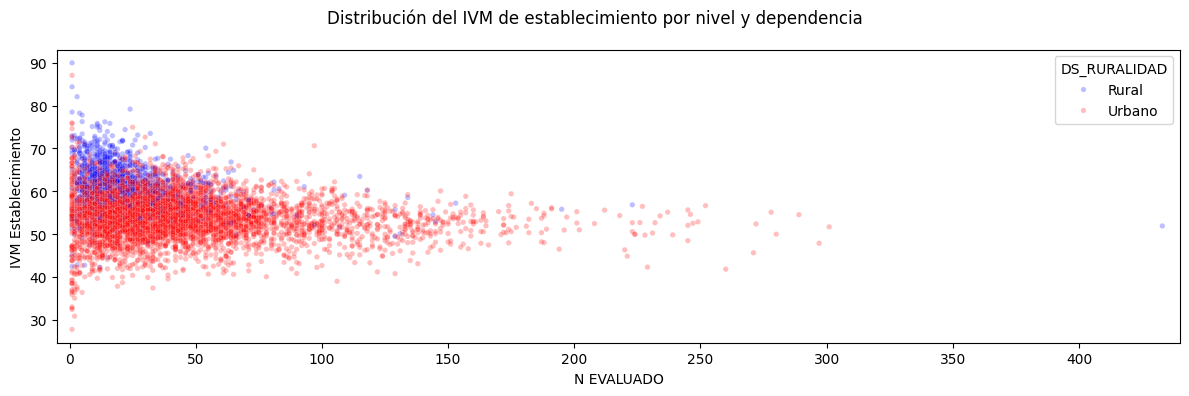

In [22]:
palette = {
    'Urbano': '#ff0000',
    'Rural': '#0000ff'}

fig, ax = plt.subplots(figsize=(12, 4))

sns.scatterplot(data=df_parvularia_raw, x='N EVALUADO', y='IVM Establecimiento', ax=ax, hue='DS_RURALIDAD', palette=palette,
                   s=15, alpha=0.25)
ax.set_xlim(-5, 440)

fig.suptitle('Distribución del IVM de establecimiento por nivel y dependencia')

plt.tight_layout()
plt.show()

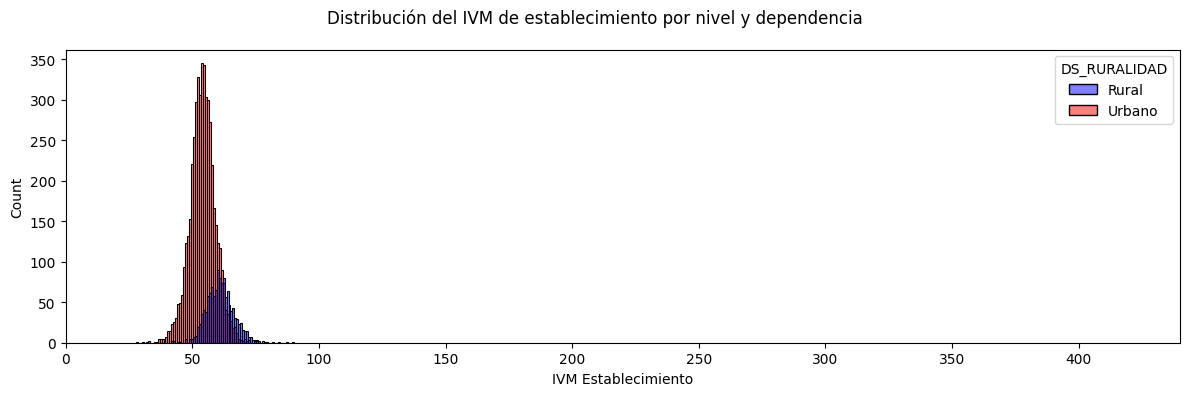

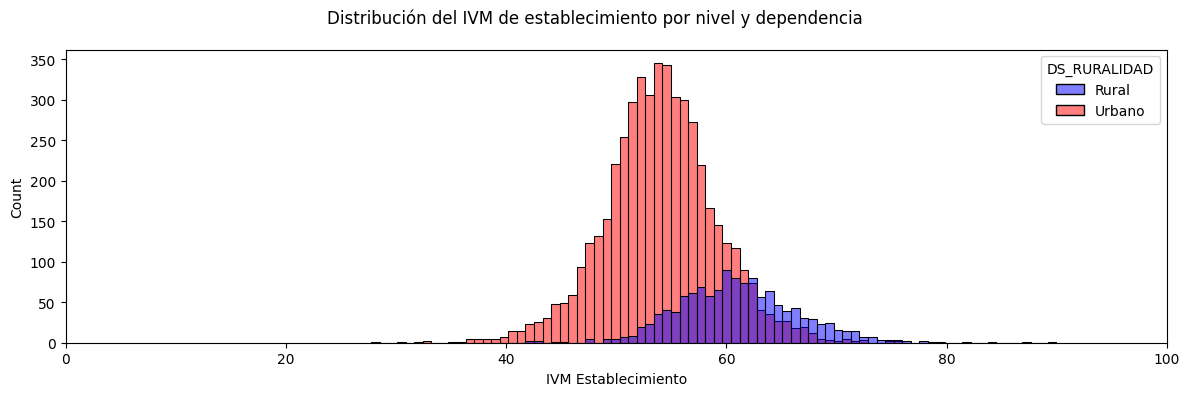

In [23]:
palette = {
    'Urbano': '#ff0000',
    'Rural': '#0000ff'}

fig, ax = plt.subplots(figsize=(12, 4))

sns.histplot(data=df_parvularia_raw, x='IVM Establecimiento', ax=ax, hue='DS_RURALIDAD', palette=palette)
ax.set_xlim(0, 440)

fig.suptitle('Distribución del IVM de establecimiento por nivel y dependencia')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))

sns.histplot(data=df_parvularia_raw, x='IVM Establecimiento', ax=ax, hue='DS_RURALIDAD', palette=palette)
ax.set_xlim(0, 100)

fig.suptitle('Distribución del IVM de establecimiento por nivel y dependencia')

plt.tight_layout()
plt.show()

Como se puede ver en el primer gráfico, al aumentar los estudiantes evaluados por establecimiento, el la disperción del IVM si se reduce, tendiendo a lo que se ve, aproximadamente, 50. Esto también coincide con la distribución de IVM, (histograma) por lo que concluyo que la tendecia a ~50, cuando los encuestados aumentan, quiere decir que un estudiante promedio, tendría un IVM de ~50, a nivel nacional.